### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

### Load Dataset

In [2]:
credit = pd.read_csv("cleaned_credit_card.csv")
customer = pd.read_csv("cleaned_customer.csv")

### Merge Both Datasets

In [3]:
df = pd.merge(
    credit,
    customer,
    on="Client_Num",
    how="inner"
)

### Basic Information

In [4]:
df.head()


,Client_Num,Card_Category,Annual_Fees,Activation_30_Days,Customer_Acq_Cost,Week_Start_Date,Week_Num,Qtr,current_year,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Vol,Avg_Utilization_Ratio,Use Chip,Exp Type,Interest_Earned,Delinquent_Acc,Customer_Age,Gender,Dependent_Count,Education_Level,Marital_Status,state_cd,Zipcode,Car_Owner,House_Owner,Personal_loan,contact,Customer_Job,Income,Cust_Satisfaction_Score
0,708082083,Blue,200,0,87.0,1/1/2023,Week-1,Q1,2023,3544.0,1661,15149,111,0.469,Chip,Travel,4393.21,0,24,F,1,Uneducated,Single,FL,91750,No,yes,no,Unknown,Businessman,202326.0,3.0
1,708083283,Blue,445,1,108.0,1/1/2023,Week-1,Q1,2023,3544.0,2517,992,21,0.736,Swipe,Entertainment,69.44,0,62,F,0,Unknown,Single,NJ,91750,No,no,no,Cellular,Selfemployeed,5225.0,2.0
2,708084558,Blue,140,0,106.0,1/1/2023,Week-1,Q1,2023,8258.0,1771,1447,23,0.214,Swipe,Entertainment,202.58,0,32,F,1,Unknown,Married,NJ,91750,Yes,no,no,Unknown,Selfemployeed,14235.0,2.0
3,708085458,Blue,250,1,106.0,1/1/2023,Week-1,Q1,2023,1438.3,0,3940,82,0.000,Swipe,Grocery,236.40,0,38,M,2,Uneducated,Married,NY,91750,No,no,no,Unknown,Selfemployeed,45683.0,1.0
4,708086958,Blue,320,1,106.0,1/1/2023,Week-1,Q1,2023,3128.0,749,4369,59,0.239,Swipe,Fuel,1004.87,1,48,M,4,Graduate,Single,TX,91750,Yes,yes,no,Cellular,Selfemployeed,14254.0,1.0


In [5]:
df.shape

(10108, 32)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10108 entries, 0 to 10107
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Client_Num               10108 non-null  int64  
 1   Card_Category            10108 non-null  object 
 2   Annual_Fees              10108 non-null  int64  
 3   Activation_30_Days       10108 non-null  int64  
 4   Customer_Acq_Cost        10108 non-null  float64
 5   Week_Start_Date          10108 non-null  object 
 6   Week_Num                 10108 non-null  object 
 7   Qtr                      10108 non-null  object 
 8   current_year             10108 non-null  int64  
 9   Credit_Limit             10108 non-null  float64
 10  Total_Revolving_Bal      10108 non-null  int64  
 11  Total_Trans_Amt          10108 non-null  int64  
 12  Total_Trans_Vol          10108 non-null  int64  
 13  Avg_Utilization_Ratio    10108 non-null  float64
 14  Use Chip              

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Client_Num,10108.0,7.390104e+08,3.673623e+07,7.080821e+08,7.130267e+08,7.179037e+08,7.727989e+08,8.278908e+08
Annual_Fees,10108.0,2.918495e+02,1.183394e+02,9.500000e+01,1.950000e+02,2.950000e+02,3.950000e+02,5.000000e+02
Activation_30_Days,10108.0,5.746933e-01,4.944139e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Customer_Acq_Cost,10108.0,9.623447e+01,2.572033e+01,4.000000e+01,7.900000e+01,9.500000e+01,1.120000e+02,1.720000e+02
current_year,10108.0,2.023000e+03,0.000000e+00,2.023000e+03,2.023000e+03,2.023000e+03,2.023000e+03,2.023000e+03
Credit_Limit,10108.0,8.644771e+03,9.082282e+03,1.438300e+03,2.559750e+03,4.571000e+03,1.111425e+04,3.451600e+04
Total_Revolving_Bal,10108.0,1.162792e+03,8.151607e+02,0.000000e+00,3.555000e+02,1.276500e+03,1.784000e+03,2.517000e+03
Total_Trans_Amt,10108.0,4.404631e+03,3.397911e+03,5.100000e+02,2.155750e+03,3.899500e+03,4.741000e+03,1.848400e+04
Total_Trans_Vol,10108.0,6.486456e+01,2.347511e+01,1.000000e+01,4.500000e+01,6.700000e+01,8.100000e+01,1.390000e+02
Avg_Utilization_Ratio,10108.0,2.745714e-01,2.756758e-01,0.000000e+00,2.200000e-02,1.750000e-01,5.020000e-01,9.990000e-01


In [8]:
df.describe(include="object").T

,count,unique,top,freq
Card_Category,10108,4,Blue,9314
Week_Start_Date,10108,52,2/7/2023,195
Week_Num,10108,52,Week-27,195
Qtr,10108,4,Q2,2535
Use Chip,10108,3,Swipe,7121
Exp Type,10108,6,Bills,2938
Gender,10108,2,F,5880
Education_Level,10108,6,Graduate,4058
Marital_Status,10108,3,Married,5165
state_cd,10108,28,CA,2468


### Check Missing Values

In [9]:
df.isnull().sum()

Client_Num                 0
Card_Category              0
Annual_Fees                0
Activation_30_Days         0
Customer_Acq_Cost          0
Week_Start_Date            0
Week_Num                   0
Qtr                        0
current_year               0
Credit_Limit               0
Total_Revolving_Bal        0
Total_Trans_Amt            0
Total_Trans_Vol            0
Avg_Utilization_Ratio      0
Use Chip                   0
Exp Type                   0
Interest_Earned            0
Delinquent_Acc             0
Customer_Age               0
Gender                     0
Dependent_Count            0
Education_Level            0
Marital_Status             0
state_cd                   0
Zipcode                    0
Car_Owner                  0
House_Owner                0
Personal_loan              0
contact                    0
Customer_Job               0
Income                     0
Cust_Satisfaction_Score    0
dtype: int64

### Duplicate Records

In [10]:
df.duplicated().sum()

0

# Distribution of Revenue

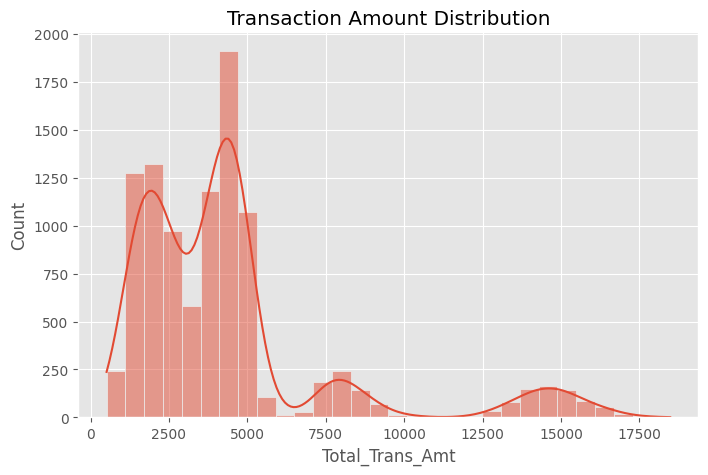

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total_Trans_Amt"],
    bins=30,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

# Credit Limit Distribution

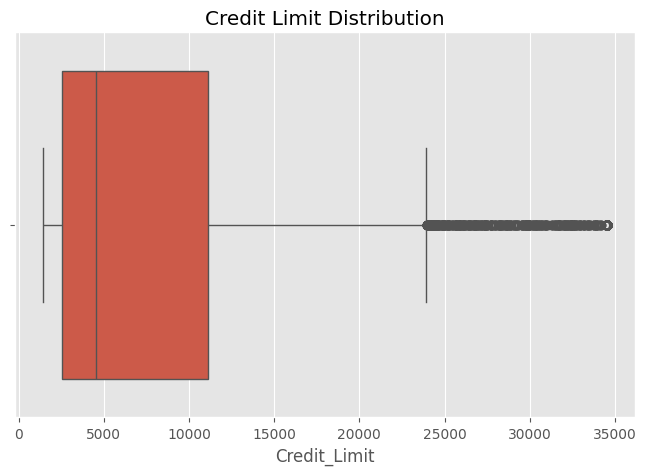

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Credit_Limit"]
)

plt.title("Credit Limit Distribution")

plt.show()

# Revenue by Card Category

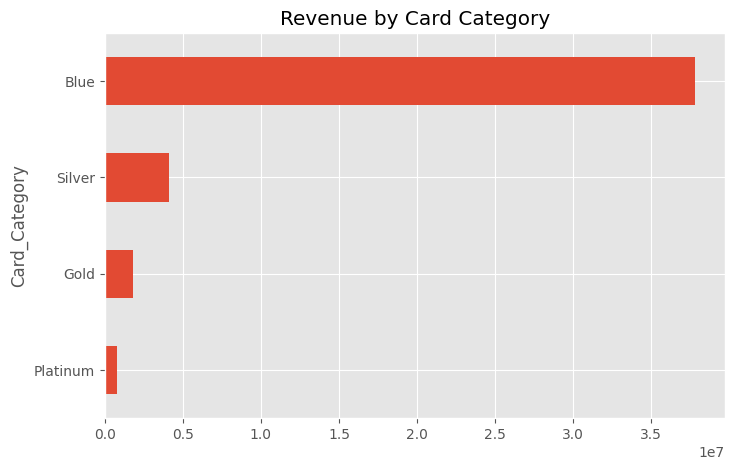

In [13]:
df.groupby("Card_Category")["Total_Trans_Amt"]\
.sum()\
.sort_values()\
.plot(
kind="barh",
figsize=(8,5)
)

plt.title("Revenue by Card Category")

plt.show()

# Revenue by Customer Job

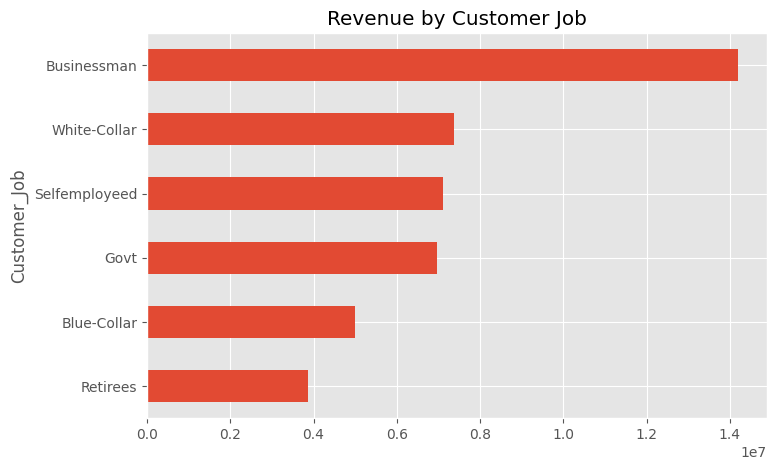

In [14]:
job=df.groupby(
"Customer_Job"
)["Total_Trans_Amt"].sum().sort_values()

job.plot(
kind="barh",
figsize=(8,5)
)

plt.title("Revenue by Customer Job")

plt.show()

# Revenue by State

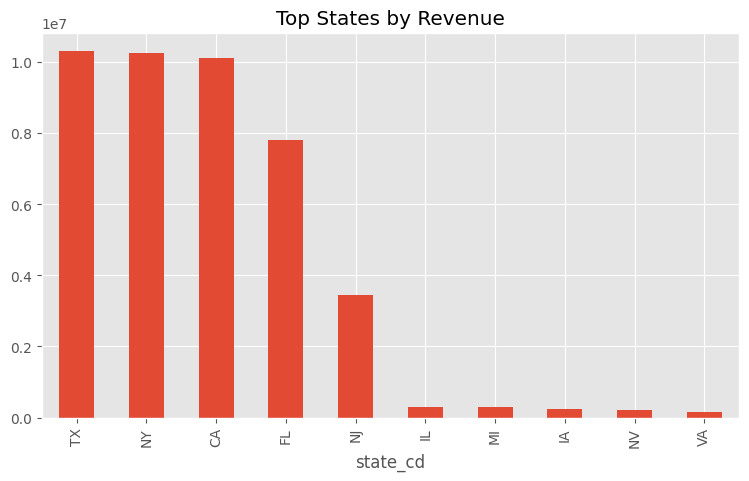

In [19]:
state=df.groupby(
"state_cd"
)["Total_Trans_Amt"].sum()

state.nlargest(10).plot(
kind="bar",
figsize=(9,5)
)

plt.title("Top States by Revenue")

plt.show()

# Spending Categories

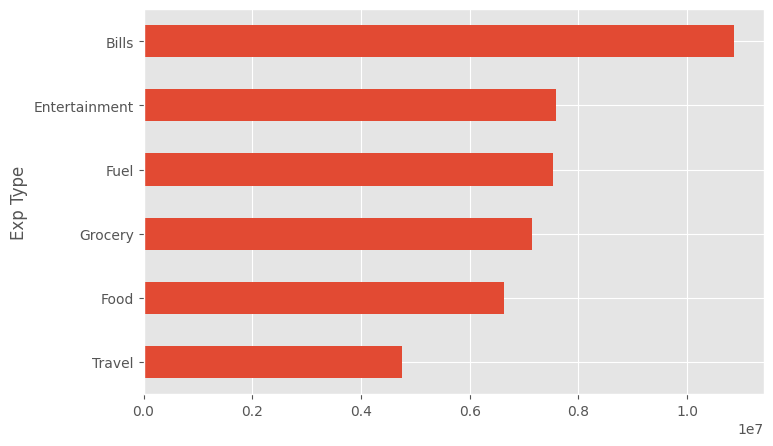

In [22]:
expense=df.groupby(
"Exp Type"
)["Total_Trans_Amt"].sum()

expense.sort_values().plot(
kind="barh",
figsize=(8,5)
)

plt.show()

# Transaction Method

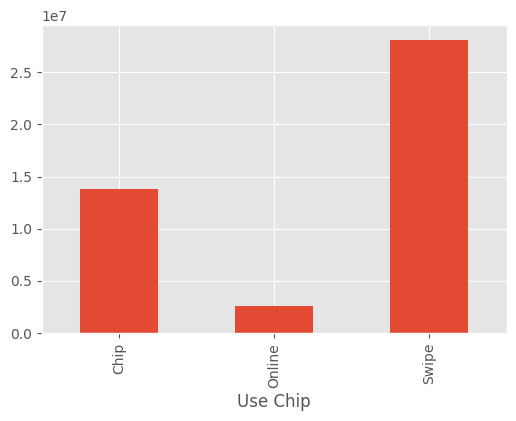

In [24]:
chip=df.groupby(
"Use Chip"
)["Total_Trans_Amt"].sum()

chip.plot(
kind="bar",
figsize=(6,4)
)

plt.show()

# Revenue by Gender

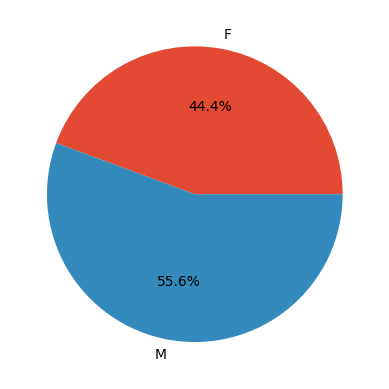

In [25]:
gender=df.groupby(
"Gender"
)["Total_Trans_Amt"].sum()

gender.plot(
kind="pie",
autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

# Revenue by Education

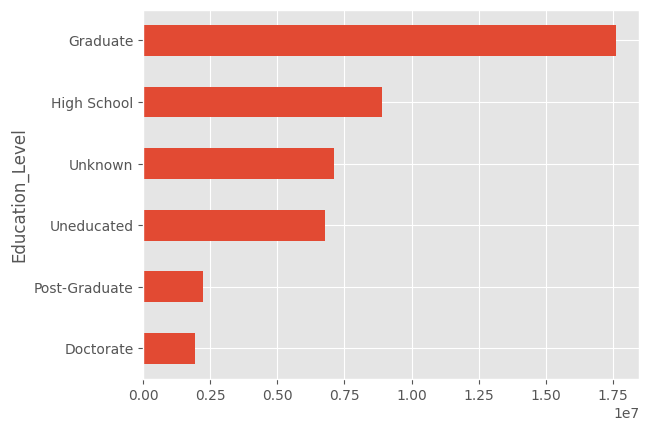

In [26]:
edu=df.groupby(
"Education_Level"
)["Total_Trans_Amt"].sum()

edu.sort_values().plot(
kind="barh"
)

plt.show()

# Correlation Heatmap

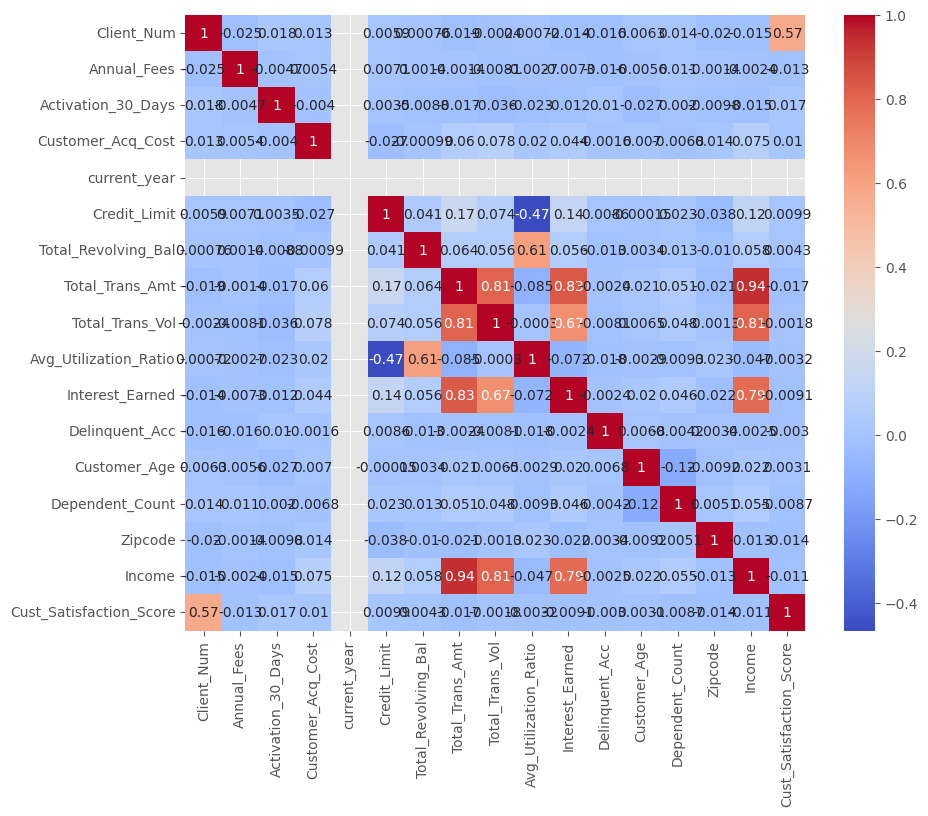

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(

df.select_dtypes(include=np.number).corr(),

annot=True,

cmap="coolwarm"

)

plt.show()

# Customer Age Distribution

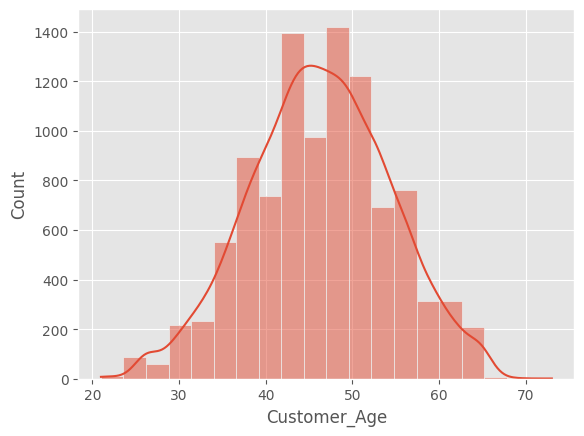

In [29]:
sns.histplot(
df["Customer_Age"],
bins=20,
kde=True
)

plt.show()

# Final Outcomes